# Module 5: Software for Data Analysis - Python Univariate and Bivariate Analysis


Xiao Chen

Oct. 03, 2026

In this notebook, I will explore and analyze the Titanic dataset using descriptive statistics and data visualizations. I will examine categorical and numerical variables, compare relationships between variables, and identify important patterns in passenger class, age, fare, and survival. The analysis will focus on describing observed relationships without making unsupported causal claims.


This notebook is organized in following steps:

1. Setup and Data Review
2. Univariate Categorical Analysis
3. Univariate Numerical Analysis
4. Categorical-to-Categorical Comparison
5. Categorical-to-Numerical Comparison
6. Visualizations
7. Final Findings


# 1. Setup an Data Review

### 1A. Download the CSV from url.
Use the Titanic CSV dataset provided through the official pandas project:
https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv

The dataset titanic.csv contains one row for each passenger and columns describing characteristics such as passenger class, age, fare, cabin, embarkation point, and survival status.

At this stage, we are only downloading the CSV file.

The code first checks whether the file is already available in the current Colab session. If it is, the download is skipped. If it is not, the file is downloaded from url.

### What Each Package Does

**`from pathlib import Path`**
* **What it is:** A built-in Python tool for handling folder locations and filenames.
* **Why use it:** Instead of worrying about slash directions (`/` vs `\`) across different operating systems (Windows vs. Mac/Linux), `Path` makes file paths safe, readable, and easy to join.


**`import pandas as pd`**
* **What it is:** The standard library for working with tabular data (spreadsheets).
* **Why use it:** Pandas allows us to load CSV files, clean missing values, filter rows, group numbers, and compute statistics. The `as pd` part is an industry-standard shortcut so we don't have to type `pandas` every time.


**`import urllib.request`**
* **What it is:** A Python module that provides tools for downloading and working with data from URLs.
* **Why use it:** `urllib.request.urlretrieve()`  lets us download a file directly from a URL and save it to a specific location on your computer or notebook. In our example, we use it to download the Titanic CSV file from GitHub.

**`import matplotlib.pyplot as plt`**
* **What it is:**
* **Why use it:**

In [1]:
from pathlib import Path
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt

data_url = 'https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv'

DATA_PATH = Path('/content/titanic.csv')

if not DATA_PATH.exists():
    urllib.request.urlretrieve(data_url, DATA_PATH)

print('CSV ready:', DATA_PATH.name)
print('File size (MB):', round(DATA_PATH.stat().st_size / 1_000_000, 1))

CSV ready: titanic.csv
File size (MB): 0.1


### 1B. Data Import
- `read_csv()` reads a CSV into a table.
    - `keep_default_na=False` tells pandas not to automatically treat its usual missing-value markers (such as "NA" or "NaN") as missing.
    - `na_values=['']` tells pandas to treat empty strings as missing values (NaN).

Load the CSV file.

In [2]:
df = pd.read_csv(
    DATA_PATH,
    keep_default_na=False,
    na_values=['']
)
starting_rows = len(df)
print(f'Loaded {starting_rows:,} requests and {df.shape[1]} columns.')

Loaded 891 requests and 12 columns.


### 1C. Initial Data Preview

- `head()` shows a few records; it cannot tell
us everything about a million-row dataset.

- `tail()` shows the last few records; it helps us see what is happening at the end of a large dataset.

- `concat()` combines multiple DataFrames together; it lets us view selected parts of a dataset in one table.

- Display the first rows.


In [3]:
display(df.head(1))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


**Findings**:
- SibSp = number of siblings or spouses aboard the Titanic.
- Parch = number of parents or children aboard the Titanic.
- Each row appears to represent one passenger aboard the Titanic, including whether they survived and their passenger class.
- The columns store information such as the passenger's name, sex, age, family relationships(SibSp, Parch), ticket number, fare, cabin, and port of embarkation.

### 1D: Check shape


Display the DataFrame’s shape. In a markdown cell, explain the number of rows, the number of columns, and what those two numbers mean in this dataset.


In [4]:
df.shape

(891, 12)

**Findings**:
- The DataFrame has 891 rows and 12 columns.
- The 891 rows represent individual passengers in the Titanic dataset, while the 12 columns represent different pieces of information recorded about each passenger, such as their survival status, name, age, sex, ticket, and fare.

### 1E: Review the column names

Display the complete list of column names. In a markdown cell, identify two columns containing categorical information, two containing numerical information, and one whose meaning was not immediately obvious to you.


In [5]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

**Findings**:
- Two columns containing categorical information are Sex and Embarked, because they contain categories such as male/female and different port codes.
- Two columns containing numerical information are Age and Fare, which contain passengers' ages and ticket prices.
- The Pclass column was not immediately obvious to me because it contains numbers (1, 2, and 3), but these numbers represent passenger classes rather than a continuous numerical measurement.

### 1F: Check data types - Confirm that the required variables are available

Display the data type assigned to every column. In a markdown cell, explain the difference between at least two data types shown in the output. Identify one integer column, one decimal or floating-point column, and one text column.

In [6]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


**Findings**:
- The DataFrame contains several different data types. An integer (int64) stores whole numbers, such as PassengerId, while a floating-point (float64) stores numbers that can contain decimal values, such as Fare and Age. A text (object) column stores text values, such as passenger names in the Name column.

# 1G. Dataset Structure - Check missing values in the variables used for analysis.

- isna().sum() checks how many Passenger IDs are missing.
- duplicated().sum() checks how many Passenger IDs are repeated.

Display a structural summary.

Use info() to display a technical summary of the DataFrame. In a markdown cell, identify two useful pieces of information supplied by this output.


In [7]:
# info() reports column names, non-missing counts, and data types.
df.info()

print('Missing Passenger IDs:', df['PassengerId'].isna().sum())
print('Repeated Passenger IDs:', df['PassengerId'].duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Missing Passenger IDs: 0
Repeated Passenger IDs: 0


**Findings**:
- The info() output provides useful information about the number of non-null values in each column and the data type assigned to each column.
- For example, Age has 714 non-null values, meaning some ages are missing, and Fare has a float64 data type because it can contain decimal values.
- The output also shows that the DataFrame contains 891 rows and 12 columns.

### Missing Value

- `isna()` asks whether a value is missing.
    - In this notebook, only blank cells are treated as missing; text values such as `NA` or `NaN` are not automatically treated as missing because of the `read_csv()` settings.

- `sum()` counts those True answers.
- The percentage is the count divided by the number of missings, multiplied by 100.
- `pd.DataFrame()` creates a summary table of missing-value counts and percentages.
- `sort_values()` orders the table from the most missing values to the least.





### Calculate and display the number of missing values in every column.

In a markdown cell, answer the following questions in 3–4 complete sentences:
- Which columns contain missing values?
- Which column contains the most missing values?
- Why should an analyst identify missing values before beginning a detailed analysis?

ps: calculate percentages.

In [8]:
missing_counts = df.isna().sum()
missing_percent = 100 * missing_counts / len(df)
missing_table = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
})
display(missing_table.sort_values('missing_count', ascending=False))

,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


**Findings**:
- The columns containing missing values are Cabin, Age, and Embarked.
- The Cabin column contains the most missing values, with 687 missing entries, or 77.10% of the dataset.
- An analyst should identify missing values before beginning a detailed analysis because they can affect calculations and lead to incomplete or misleading results. Understanding where missing values occur also helps an analyst decide how to handle them appropriately.

### 1H. Produce a basic numerical summary

Use describe() to summarize the numerical columns. In a markdown cell, identify two statistics in the output and explain what each one communicates.


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Findings**:
- The mean represents the average value of a numerical column; for example, the average age of passengers with recorded ages was approximately 29.7 years.
- The 50% statistic represents the median, meaning half of the recorded values are below this value and half are above it; for Age, the median was 28 years.
- These statistics help provide a quick understanding of the typical values in the dataset.

# 1I.  Initial Data Observations

Add a markdown section titled “Initial Data Observations.” Write five numbered observations in complete sentences. Include:
- One observation about the dataset’s size
- One observation about the columns or data types
- One observation about missing values
- One observation based on the numerical summary
- One question that could be investigated through additional analysis

Your observations must describe only what the notebook output supports. Do not make causal claims or assume that a pattern exists without calculating or displaying evidence.

**Observations**:

- The dataset contains 891 rows and 12 columns, with each row representing a passenger record.

- The DataFrame contains five integer columns, two floating-point columns, and five object columns.

- Missing values are present in Age, Cabin, and Embarked, with Cabin having the most missing values at 687 entries (77.10%).

- The numerical summary shows that the median passenger age is 28 years, while the mean age among passengers with recorded ages is approximately 29.7 years.

- One question for additional analysis is: How does the number of passengers who survived compare across the different passenger classes (Pclass)?

# 2. Univariate Categorical Analysis
- Analyze Pclass using frequency counts and proportions or percentages.
- Identify the most and least common categories.
- Write a 2–3-sentence interpretation explaining the distribution.
- `value_counts()` counts how many times each unique value appears in a column.

In [10]:
counts = df["Pclass"].value_counts()
proportions = df["Pclass"].value_counts(normalize=True) * 100

pclass_summary = pd.DataFrame({
    "Passengers": counts,
    "Proportion (%)": proportions.round(2)
})

pclass_summary

,Passengers,Proportion (%)
Pclass,,
3,491,55.11
1,216,24.24
2,184,20.65


**Findings**:
- Pclass 3 is the most common category, with 491 passengers (55.11%).
- Pclass 2 is the least common, with 184 passengers (20.65%).
- Pclass 1 accounts for 216 passengers (24.24%), showing that more than half of the passengers in the dataset were traveling in third class.

# 3. Univariate Numerical Analysis
- Analyze Age or Fare using count, mean, median, standard deviation, minimum, maximum, and quartiles.
- Explain a typical value, the spread, the effect of missing values, and what the mean–median comparison may suggest.
- `describe()` provides summary statistics such as count, mean, standard deviation, minimum, maximum, and quartiles for numerical data.
- `isna().sum()` checks how many missing values are present in a column.

In [11]:
age_summary = df["Age"].describe()

print(age_summary)
print("Median:", df["Age"].median())
print("Missing values:", df["Age"].isna().sum())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
Median: 28.0
Missing values: 177


**Findings**:
- The typical passenger was around 28–30 years old, with a median age of 28 and a mean age of 29.70.
- The standard deviation of 14.53 indicates considerable variation in age, while the middle 50% of passengers were between 20.13 and 38 years old.
- There are 177 missing age values, so the statistics are based on 714 passengers; because the mean is slightly higher than the median, the distribution may be slightly right-skewed.

# 4. Categorical-to-Categorical Comparison
- Compare Pclass and Survived.
- Produce a count cross-tabulation.
  - 0: Did not survived
  - 1: Survived
  - All: total
- Produce a row-percentage cross-tabulation.
  - 0: Did not survived
  - 1: Survived
- Distinguish counts from within-group percentages.
  - **Count**: The actual number of passengers in each category.
  - **Within-group percentages**: For example, among passengers in Pclass 1, 62.96% survived and 37.04% did not survive.

- Describe an association without claiming that passenger class alone caused the observed differences.
- `pd.crosstab()` creates a frequency table showing the relationship between two categorical variables.


In [12]:
# Count cross-tabulation
pd.crosstab(df["Pclass"], df["Survived"], margins=True)


Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


In [13]:
# Row-percentage cross-tabulation
pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


**Findings**:
- There is an association between Pclass and survival in the Titanic data.
- First-class passengers had the highest survival percentage (62.96%), followed by second-class passengers (47.28%), while third-class passengers had the lowest (24.24%).
- However, this describes an association only and does not mean that passenger class alone caused the differences in survival, since other factors may also have influenced survival.

# 5. Categorical-to-Numerical Comparison
- Compare Fare across Pclass using count, mean, median, and standard deviation.
- Identify the group with the highest mean, compare group sizes, and assess whether mean and median tell similar stories.
- Add one short student-selected comparison: Age by Sex, Age by Pclass, or Fare by Embarked.
- `groupby()` groups data by a categorical variable so numerical values can be compared across groups.
- `.agg()` applies one or more summary/statistical functions to data, allowing you to calculate several statistics at the same time.

In [14]:
df.groupby("Pclass")["Fare"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
Pclass,,,,
1,216,84.154687,60.2875,78.380373
2,184,20.662183,14.2500,13.417399
3,491,13.675550,8.0500,11.778142


**Findings**:
- Pclass 1 has the highest mean fare at about 84.15, substantially higher than Pclass 2 (20.66) and Pclass 3 (13.68).
- Pclass 3 has the largest group size with 491 passengers, while Pclass 2 is the smallest with 184 passengers.
- For all three classes, the mean is higher than the median, suggesting that higher-priced fares and outliers pull the mean upward, so the median may better represent a typical fare.

In [15]:
df.groupby("Sex")["Age"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
Sex,,,,
female,261,27.915709,27.0,14.110146
male,453,30.726645,29.0,14.678201


**Findings**:
- Female passengers had a lower mean age (27.92 years) and median age (27 years) compared with male passengers, whose mean age was 30.73 years and median was 29 years.
- The standard deviations are similar (14.11 for females and 14.68 for males), indicating that the spread of ages was fairly similar between the two groups.
- Overall, male passengers in this dataset were slightly older on average than female passengers.

# 6. Visualizations
- Create one univariate visualization: a categorical bar chart or numerical histogram.
- Create one bivariate comparison chart based on a grouped analysis.
- Require a descriptive or takeaway-oriented title, clear labels, readable scale, purposeful color, and a 2–3-sentence interpretation for each chart.
- `plot()` creates a visualization directly from a pandas Series or DataFrame. ex. histograms, bar charts, line charts, and other basic charts.


<Axes: title={'center': 'Distribution of Passenger Ages'}, xlabel='Age (years)', ylabel='Number of Passengers'>

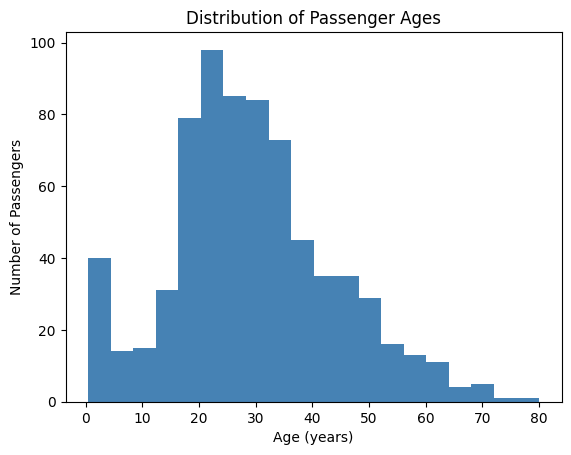

In [16]:
# Univariate visulization - histogram
df["Age"].plot(
    kind="hist",
    bins=20,
    title="Distribution of Passenger Ages",
    xlabel="Age (years)",
    ylabel="Number of Passengers",
    color="steelblue"
)

**Findings**:
- The histogram shows that passenger ages are concentrated mostly between 20 and 40 years, with fewer passengers at older ages.
- The distribution is slightly right-skewed, with some older passengers extending the distribution toward age 80.

<Axes: title={'center': 'Average Fare Increases with Passenger Class'}, xlabel='Passenger Class', ylabel='Average Fare'>

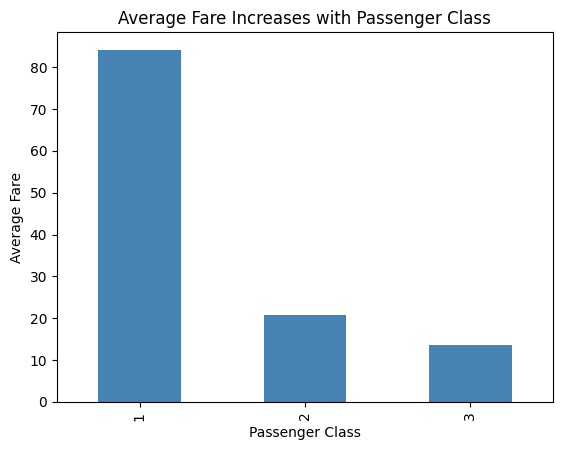

In [17]:
# Bivariate comparison - bar chart
df.groupby("Pclass")["Fare"].mean().plot(
    kind="bar",
    title="Average Fare Increases with Passenger Class",
    xlabel="Passenger Class",
    ylabel="Average Fare",
    color="steelblue"
)

**Findings**:
- The chart shows that first-class passengers paid the highest average fare, at about 84.15, compared with 20.66 for second class and 13.68 for third class.
- This shows a clear difference in average fare across passenger classes, with first-class fares substantially higher than those of the other classes.


# 7. Final Findings
- Require four findings: one categorical, one numerical, one cross-tabulation, and one grouped comparison or chart finding.
- Each finding should contain 2–3 complete sentences, refer to specific output, explain the observed pattern, and avoid unsupported causal language.


**Final Findings**:
- Categorical — Pclass
  - Pclass 3 was the most common passenger class, with 491 passengers (55.11%), while Pclass 2 was the least common, with 184 passengers (20.65%).
  - This shows that the dataset contains a substantially larger proportion of third-class passengers than first- or second-class passengers.

- Numerical — Age
  - The average passenger age was 29.70 years, while the median was 28 years, with ages ranging from 0.42 to 80 years.
  - The standard deviation of 14.53 years indicates considerable variation in passenger ages, and the higher mean compared with the median suggests a slight right-skew in the age distribution.

- Cross-Tabulation — Pclass and Survived
  - The cross-tabulation shows that 62.96% of first-class passengers survived, compared with 47.28% of second-class passengers and 24.24% of third-class passengers.
  - This indicates an association between passenger class and survival in the dataset, but it does not establish that passenger class alone caused these differences.

- Grouped Comparison — Fare by Pclass
  - Average fare differed substantially across passenger classes, with first-class passengers having the highest mean fare of 84.15, compared with 20.66 for second class and 13.68 for third class.
  - The mean was higher than the median in each class, suggesting that some higher fares may have pulled the average upward, particularly in first class.